## To do
- Figure out why the model is overfitting so quickly
- Try to improve model performance even more (look at elmo embeddings) (save this version then make changes)
- Perform hyperparameter tuning
- Figure out feature importance for the stylometric features (this has efficiency benefits)
- Clean up messy code
- Add installations for non-standard library packages
- Add documentation (including markdown and comments) to explain how this model works

# Installation Scripts

In [7]:
!python -m spacy download en_core_web_md

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 53.6 MB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


# Imports

In [8]:
from transformers import BertModel, BertTokenizer
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import spacy
from spacy.symbols import ORTH, POS
from collections import defaultdict, Counter
import math
from nltk import ngrams
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import random

# Constants

In [9]:
KAGGLE_INPUT_PREFIX = "/kaggle/input/datasets/abdullahsweesi/av-data"
TRIAL_DATA_PATH = f"{KAGGLE_INPUT_PREFIX}/AV_trial.csv"
TRAIN_DATA_PATH = f"{KAGGLE_INPUT_PREFIX}/train.csv"
VAL_DATA_PATH = f"{KAGGLE_INPUT_PREFIX}/dev.csv"
TEST_DATA_PATH = f"{KAGGLE_INPUT_PREFIX}/test.csv"
FASTTEXT_PATH = "/kaggle/input/datasets/yekenot/fasttext-crawl-300d-2m/crawl-300d-2M.vec"

nlp = spacy.load("en_core_web_md", disable=["ner"])

MAX_LEN = 256
BATCH_SIZE = 64            # For two GPUs (32 each)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Data Loading

In [10]:
trial_df = pd.read_csv(TRIAL_DATA_PATH, encoding="utf-8")
train_df = pd.read_csv(TRAIN_DATA_PATH, encoding="utf-8")
val_df = pd.read_csv(VAL_DATA_PATH, encoding="utf-8")
test_df = pd.read_csv(TEST_DATA_PATH, encoding="utf-8")

# Stylometric feature extraction

In [11]:
# makes sure that these are lowercase
TOP_FUNCTION_WORDS = set(word.lower() for word in [
    "the", "of", "and", "to", "a", "in", 
    "is", "you", "that", "was", "he", "his", 
    "for", "it", "with", "as", "on", "are",
    "be", "at", "by", "they", "this", "from", 
    "i", "have", "or", "had", "not", "she"
])
SORTED_TOP_FUNCTION_WORDS = sorted(list(TOP_FUNCTION_WORDS))

FUNCTION_TAGS = {"ADP", "AUX", "CONJ", "CCONJ", "DET", "PART", "PRON", "SCONJ"}
CONTENT_TAGS = {"ADJ", "ADV", "INTJ", "NOUN", "NUM", "PROPN", "VERB"}

NON_WORD_TAGS = {"NUM", "PUNCT", "SYM", "X"}

ALL_NN_FORMS = {"NN", "NNS", "NNP", "NNPS"}                # all noun forms
ALL_JJ_FORMS = {"JJ", "JJR", "JJS"}                        # all adjective forms
ALL_RB_FORMS = {"RB", "RBR", "RBS"}                        # all adverb forms
ALL_VB_FORMS = {"VB", "VBD", "VBG", "VBN", "VBP", "VBZ"}   # all verb forms

def get_top_pos_trigrams():
    trigrams = set()

    for nn in ALL_NN_FORMS:
        trigrams.add((nn, "IN", "DT"))
        trigrams.add(("IN", "DT", nn))
        trigrams.add(("DT", nn, "IN"))
        trigrams.add(("DT", nn, "PUNCT"))
        for nn2 in ALL_NN_FORMS:
            trigrams.add(("DT", nn, nn2))

    for jj in ALL_JJ_FORMS:
        trigrams.add(("IN", "DT", jj))
        for nn in ALL_NN_FORMS:
            trigrams.add(("DT", jj, nn))
            trigrams.add((jj, nn, "IN"))
            trigrams.add((jj, nn, "PUNCT"))
            for rb in ALL_RB_FORMS:
                trigrams.add((rb, jj, nn))

    for vb in ALL_VB_FORMS:
        trigrams.add(("PRP", vb, "DT"))
        trigrams.add(("PRP", vb, "IN"))

    return trigrams
                
TOP_POS_TRIGRAMS = get_top_pos_trigrams()
SORTED_TOP_POS_TRIGRAMS = sorted(list(TOP_POS_TRIGRAMS))
# print(len(TOP_POS_TRIGRAMS))


def extract_stylometric_features(document):
    """
    Processes a spaCy document and returns a []-dimensional feature vector
    """
    f_count, c_count = 0, 0                          # counts of function and content words
    top_function_word_freqs = defaultdict(int)       # frequencies of top function words
    lexical_count = 0                                # count of all words
    unique_words = set()                             # set of all words (no duplicates)
    conjunction_count = 0                            # count of all conjunction words
    long_word_count = 0                              # long word (>6 chars) count
    oov_count, non_oov_count = 0, 0                  # counts of oov and vocabulary words
    word_length_sum = 0                              # sum of all word lengths
    pronoun_freqs = {                                # frequencies of various pronoun types
        "1S": 0,                             # first-person singular
        "1P": 0,                             # first-person plural
        "12": 0,                             # first- and second-person
        "3": 0                               # third-person
    }
    special_punct_freqs = defaultdict(int)           # frequencies of each of ";,.-?!"
    total_punct_count = 0                            # total punctuation count
    top_pos_trigram_freqs = defaultdict(int)         # frequencies of the top POS trigrams
    total_pos_trigram_count = 0                      # total POS trigram count

    # loop over all tokens
    for token in document:
        if token.is_space:
            continue

        text_lower = token.text.lower()
        universal_pos = token.pos_

        # word statistics
        if universal_pos not in NON_WORD_TAGS:
            unique_words.add(text_lower)
            lexical_count += 1
            word_length_sum += len(token.text)

            if text_lower in TOP_FUNCTION_WORDS:
                top_function_word_freqs[text_lower] += 1

            if universal_pos in FUNCTION_TAGS:
                f_count += 1
            elif universal_pos in CONTENT_TAGS:
                c_count += 1

            if universal_pos in ["CONJ", "CCONJ"]:
                conjunction_count += 1
            
            if len(token.text) > 6:
                long_word_count += 1

            if token.is_oov:
                oov_count += 1
            else:
                non_oov_count += 1

        # punctuation statistics
        if universal_pos == "PUNCT":
            total_punct_count += 1
            if token.text in ";,.-?!":
                special_punct_freqs[token.text] += 1

        # personal pronoun statistics
        if universal_pos == "PRON" and "Prs" in token.morph.get("PronType"):
            person = token.morph.get("Person")
            num = token.morph.get("Number")
            if "1" in person:
                pronoun_freqs["12"] += 1
                if "Sing" in num:
                    pronoun_freqs["1S"] += 1
                else:
                    pronoun_freqs["1P"] += 1
            elif "2" in person:
                pronoun_freqs["12"] += 1
            elif "3" in person:
                pronoun_freqs["3"] += 1

    # extract Penn Treebank POS tags
    ptb_tags = [token.tag_ for token in document]

    # loop over all POS trigrams
    for tri in ngrams(ptb_tags, 3):
        total_pos_trigram_count += 1
        if tri in TOP_POS_TRIGRAMS:
            top_pos_trigram_freqs[tri] += 1

    # sentence statistics
    sentence_lengths = [len([t for t in s if not t.is_space]) for s in document.sents]
    mean_sentence_length = np.mean(sentence_lengths) if sentence_lengths else 0
    if len(sentence_lengths) > 1:
        variance = sum((length - mean_sentence_length)**2 for length in sentence_lengths) / len(sentence_lengths)
        std_sentence_length = math.sqrt(variance)
    else:
        std_sentence_length = 0

    # final feature assembly
    feature_vector = []

    # the (normalised) frequencies of each of the top 30 function words [30 features]
    for word in SORTED_TOP_FUNCTION_WORDS:
        feature_vector.append(top_function_word_freqs[word] / (f_count + 1e-9))

    # the (normalised) ratio of function words to content words [1 feature]
    feature_vector.append(np.clip(f_count / (c_count + 1e-9), 0, 5))

    # the (normalised) type-token ratio (i.e proportion of non-unique words) [1 feature]
    feature_vector.append(len(unique_words) / (lexical_count + 1e-9))

    # the (normalised) count of conjunctions (e.g. and, but) [1 feature]
    feature_vector.append(conjunction_count / (f_count + 1e-9))

    # the (normalised) count of long words (>6 chars) [1 feature]
    feature_vector.append(long_word_count / (lexical_count + 1e-9))

    # the (normalised) ratio of OOV words to non-OOV words [1 feature]
    feature_vector.append(np.clip(oov_count / (non_oov_count + 1e-9), 0, 5))

    # the (normalised) ratio of first- and second-person pronouns to third-person pronouns [1 feature]
    feature_vector.append(np.clip(pronoun_freqs["12"] / (pronoun_freqs["3"] + 1e-9), 0, 5))

    # the (normalised) ratio of first-person singular pronouns to first-person plural pronouns [1 feature]
    feature_vector.append(np.clip(pronoun_freqs["1S"] / (pronoun_freqs["1P"] + 1e-9), 0, 5))

    # the mean word length [1 feature]
    feature_vector.append(np.clip(word_length_sum / (lexical_count + 1e-9), 0, 20))

    # the mean sentence length [1 feature]
    feature_vector.append(np.clip(mean_sentence_length, 0, 100))

    # the sentence length standard deviation [1 feature]
    feature_vector.append(np.clip(std_sentence_length, 0, 100))

    # the (normalised) frequencies of punctuation symbols in ';,.-?!' [6 features]
    for symbol in ";,.-?!":
        feature_vector.append(special_punct_freqs[symbol] / (total_punct_count + 1e-9))

    # the (normalised) ratios of punctuation symbol pairs of interest [6 features]
    punctuation_pairs = [
        (",", ";"), (",", "-"),
        (";", "-"), ("?", "."),
        (",", "."), ("!", ".")
    ]
    for s1, s2 in punctuation_pairs:
        feature_vector.append(np.clip(special_punct_freqs[s1] / (special_punct_freqs[s2] + 1e-9), 0, 5))

    # the (normalised) counts of the top POS trigrams [119 features]
    for tri in SORTED_TOP_POS_TRIGRAMS:
        feature_vector.append(top_pos_trigram_freqs[tri] / (total_pos_trigram_count + 1e-9))

    return np.array(feature_vector)

def process_input_stylometry(df):
    feature_vectors_1 = []
    feature_vectors_2 = []

    for document in nlp.pipe(df["text_1"], batch_size=256, n_process=-1, disable=["ner", "lemmatizer"]):
        feature_vectors_1.append(extract_stylometric_features(document))

    for document in nlp.pipe(df["text_2"], batch_size=256, n_process=-1, disable=["ner", "lemmatizer"]):
        feature_vectors_2.append(extract_stylometric_features(document))
        
    return np.array(feature_vectors_1), np.array(feature_vectors_2)

In [12]:
train_style_1, train_style_2 = process_input_stylometry(train_df)
val_style_1, val_style_2 = process_input_stylometry(val_df)
test_style_1, test_style_2 = process_input_stylometry(test_df)

In [13]:
# Different features can have different ranges, so we need to scale them

combined_train_style = np.vstack([train_style_1, train_style_2])
combined_val_style = np.vstack([val_style_1, val_style_2])
combined_test_style = np.vstack([test_style_1, test_style_2])

# Scaler based only on trianing data to prevent leakage

# scaler = StandardScaler().fit(combined_train_style)
scaler = MinMaxScaler().fit(combined_train_style)

# Scale all features
train_style_scaled_1 = scaler.transform(train_style_1)
train_style_scaled_2 = scaler.transform(train_style_2)

val_style_scaled_1 = scaler.transform(val_style_1)
val_style_scaled_2 = scaler.transform(val_style_2)

test_style_scaled_1 = scaler.transform(test_style_1)
test_style_scaled_2 = scaler.transform(test_style_2)

# Compute the difference
train_style_diff = np.abs(train_style_scaled_1 - train_style_scaled_2)
val_style_diff = np.abs(val_style_scaled_1 - val_style_scaled_2)
test_style_diff = np.abs(test_style_scaled_1 - test_style_scaled_2)
print(train_style_diff.shape)

(27643, 171)


In [14]:
count = 0
for row in train_style_diff:
    count += sum(row == 0)

print(count / len(train_style_diff))

127.6189993850161


# Word Embedding Generation

In [15]:
class MyEmbedder:
    def __init__(self):
        self.embedding_dim = 300
        self.vocab = self.build_vocab(pd.concat([train_df, val_df], ignore_index=True))
        self.embedding_matrix = self.load_fasttext_embeddings(self.vocab)

    def tokenize(self, text):
        return [token.text.lower() for token in nlp.tokenizer(str(text))]

    def build_vocab(self, df, max_vocab=50_000):
        counter = Counter()
        for _, row in df.iterrows():
            counter.update(self.tokenize(row["text_1"]))
            counter.update(self.tokenize(row["text_2"]))
    
        # build a vocab (token -> index)
        vocab = {"<PAD>": 0, "<UNK>": 1}
        latest_index = 2
        for word, _ in counter.most_common(max_vocab):
            vocab[word] = latest_index
            latest_index += 1
    
        return vocab

    def load_fasttext_embeddings(self, vocab):
        matrix = np.zeros((len(vocab), self.embedding_dim))
        matrix[1] = np.random.normal(scale=0.6, size=(self.embedding_dim,))     # randomise UNK embeddings
    
        with open(FASTTEXT_PATH, "r", encoding="utf-8") as file:
            next(file)
            for line in file:
                parts = line.rstrip().split()
                word = parts[0]
                if word in vocab:
                    embedding = np.asarray(parts[1:], dtype="float32")
                    matrix[vocab[word]] = embedding
    
        return torch.from_numpy(matrix).float()

    def text_to_indices(self, text):
        tokens = self.tokenize(text)[:MAX_LEN]
        indices = [self.vocab.get(t, 1) for t in tokens]
        padding = [0] * (MAX_LEN - len(indices))
        return indices + padding

# Data Preparation

In [16]:
class AVDataset(Dataset):
    def __init__(self, df, embedder, style_diff):
        assert len(df) == len(style_diff), "df size is not the same as style_diff"

        self.ids = df["id"] if "id" in df.columns else np.arange(len(df))
        self.text_1 = df["text_1"].values
        self.text_2 = df["text_2"].values
        self.labels = df["label"].values
        self.embedder = embedder
        self.style_diff = style_diff

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        return {
            "id": self.ids[index],
            "text_1": torch.tensor(self.embedder.text_to_indices(self.text_1[index])),
            "text_2": torch.tensor(self.embedder.text_to_indices(self.text_2[index])),
            "style_diff": torch.tensor(self.style_diff[index], dtype=torch.float32),
            "label": torch.tensor(self.labels[index], dtype=torch.float32),
        }

class AVTestDataset(Dataset):
    def __init__(self, df, embedder, style_diff):
        assert len(df) == len(style_diff), "df size is not the same as style_diff"

        self.ids = df["id"] if "id" in df.columns else np.arange(len(df))
        self.text_1 = df["text_1"].values
        self.text_2 = df["text_2"].values
        self.embedder = embedder
        self.style_diff = style_diff

    def __len__(self):
        return len(self.style_diff)

    def __getitem__(self, index):
        return {
            "id": self.ids[index],
            "text_1": torch.tensor(self.embedder.text_to_indices(self.text_1[index])),
            "text_2": torch.tensor(self.embedder.text_to_indices(self.text_2[index])),
            "style_diff": torch.tensor(self.style_diff[index], dtype=torch.float32),
        }

In [17]:
my_embedder = MyEmbedder()

train_dataset = AVDataset(train_df, my_embedder, train_style_diff)
val_dataset = AVDataset(val_df, my_embedder, val_style_diff)
test_dataset = AVTestDataset(test_df, my_embedder, test_style_diff)

# Model Configuration

In [31]:
class AttentionPooling(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()

        self.attention = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, h):
        attention_weights = self.attention(h)
        attention_weights = torch.softmax(attention_weights, dim=1)

        return torch.sum(attention_weights * h, dim=1)

In [32]:
class SiameseNN(nn.Module):
    def __init__(
        self, 
        embedding_matrix, 
        lstm_hidden_dim=128, 
        semantic_output_dim=256, 
        feature_config={"u_v": False, "diff": True, "product": True},
        lstm_layers=1, 
        style_input_dim=171, 
        style_output_dim=64, 
        final_output_dim=32,
        dropout=0.5
    ):
        super().__init__()
        self.feature_config = feature_config

        semantic_input_dim = lstm_hidden_dim * 2 * 2      # for bidirectional LSTM and 2 poolings

        multiplier = 0
        if feature_config.get("u_v"):
            multiplier += 2
        if feature_config.get("diff"):
            multiplier += 1
        if feature_config.get("product"):
            multiplier += 1
        
        self.embedding = nn.Embedding.from_pretrained(embedding_matrix, freeze=True, padding_idx=0)

        self.spatial_dropout = nn.Dropout2d(0.2)
        
        self.lstm = nn.LSTM(
            300,
            lstm_hidden_dim,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if lstm_layers > 1 else 0
        )

        self.attention = AttentionPooling(lstm_hidden_dim * 2)

        # Taking inspiration from SBERT (u, v, (u - v))
        self.semantic_fc = nn.Sequential(
            nn.Linear(semantic_input_dim * multiplier, semantic_output_dim),          # input dim based on feature combination
            nn.ReLU(),
            nn.BatchNorm1d(semantic_output_dim),
            nn.Dropout(dropout)
        )

        self.style_fc = nn.Sequential(
            nn.Linear(style_input_dim, style_output_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        
        self.classifier = nn.Sequential(
            nn.Linear(semantic_output_dim + style_output_dim, final_output_dim),
            nn.ReLU(),
            nn.Linear(final_output_dim, 1)             # produce one raw logit
        )

    def encode(self, indices):
        embedded = self.embedding(indices)
        embedded = self.spatial_dropout(
            embedded.unsqueeze(1).transpose(1, 3)       # add dimension and place embedding channel in position
        ).transpose(1, 3).squeeze(1)                    # readjust embedding channel and remove extra dimension
        
        h, _ = self.lstm(embedded)
        
        # mean_pool = torch.mean(h, dim=1)
        attention_pool = self.attention(h)
        max_pool, _ = torch.max(h, dim=1)
        # return torch.cat([mean_pool, max_pool], dim=1)
        return torch.cat([attention_pool, max_pool], dim=1)
    
    def forward(self, text_1, text_2, style_diff):
        u = self.encode(text_1)
        v = self.encode(text_2)

        # Process semantic features (different combinations can be toggled on/off)
        features = []
        if self.feature_config.get("u_v"):
            features.extend([u, v])
        if self.feature_config.get("diff"):
            features.append(torch.abs(u - v))
        if self.feature_config.get("product"):
            features.append(u * v)
            
        semantic_combined = torch.cat(features, dim=1)
        
        semantic_output = self.semantic_fc(semantic_combined)
        style_output = self.style_fc(style_diff)

        # Late fusion
        output = torch.cat((semantic_output, style_output), dim=1)
        
        return self.classifier(output)

In [ ]:
# Suggestions:
#  Add a self-attention pooling layer
#  Try different semantic concatenation combinations

# Training
(with some hyperparameter tuning)

In [33]:
# Training loop


param_grid = {
    "lstm_hidden_dim": [256],
    "semantic_output_dim": [256, 128, 64],
    "feature_config": [
        {"u_v": False, "diff": True, "product": True},
        {"u_v": True, "diff": True, "product": False},
        {"u_v": True, "diff": False, "product": False},
        {"u_v": False, "diff": True, "product": False},
        {"u_v": False, "diff": False, "product": True},
        {"u_v": True, "diff": True, "product": True}
    ],
    "lstm_layers": [1, 2, 3],
    "style_output_dim": [256, 128, 64],
    "final_output_dim": [128, 64, 32, 16],
    "dropout": [0.3, 0.4, 0.5],
    "learning_rate": [2e-4, 5e-4],
    "weight_decay": [0, 1e-5, 1e-4],
    "batch_size": [128, 64]
}

histories = []
global_best_val_loss = float("inf")
global_best_state_dict = None
global_best_hyperparameters = None
patience = 3

# Scaler

scaler = GradScaler()                      # For mixed precision (optimisation)


for i in range(15):
    # Choose hyperparameter configuration
    hyperparameters = {
        "lstm_hidden_dim": random.choices(param_grid["lstm_hidden_dim"])[0],
        "semantic_output_dim":random.choices(param_grid["semantic_output_dim"])[0],
        "feature_config":random.choices(param_grid["feature_config"])[0],
        "lstm_layers": random.choices(param_grid["lstm_layers"])[0],
        "style_output_dim": random.choices(param_grid["style_output_dim"])[0],
        "final_output_dim": random.choices(param_grid["final_output_dim"])[0],
        "dropout": random.choices(param_grid["dropout"])[0],
        "learning_rate": random.choices(param_grid["learning_rate"])[0],
        "weight_decay": random.choices(param_grid["weight_decay"])[0],
        "batch_size": random.choices(param_grid["batch_size"])[0],
    }

    print(hyperparameters)

    history = {
        "train_loss": [],
        "val_loss": [],
        "hyperparameters": hyperparameters
    }

    # Model initialisation


    model = SiameseNN(
        my_embedder.embedding_matrix, 
        lstm_hidden_dim=hyperparameters["lstm_hidden_dim"],
        semantic_output_dim=hyperparameters["semantic_output_dim"],
        feature_config=hyperparameters["feature_config"],
        lstm_layers=hyperparameters["lstm_layers"],
        style_output_dim=hyperparameters["style_output_dim"],
        final_output_dim=hyperparameters["final_output_dim"],
        dropout=hyperparameters["dropout"]
    ).to(device)
    if torch.cuda.device_count() > 1:
        model = nn.DataParallel(model)
    
    # Data loading
    train_loader = DataLoader(train_dataset, batch_size=hyperparameters["batch_size"], shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=hyperparameters["batch_size"], shuffle=False)
    
    # Hyperparameters
    
    EPOCHS = 25
    
    loss_function = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        # lr=2e-4,
        lr=hyperparameters["learning_rate"],
        # weight_decay=1e-2
        weight_decay=hyperparameters["weight_decay"]
    )

    best_val_loss = float("inf")
    counter = 0
    
    
    # Training loop
    
    for epoch in range(EPOCHS):
        model.train()             # training mode
        total_train_loss = 0
        
        for batch in train_loader:
            optimizer.zero_grad(set_to_none=True)                  # reset gradients
            
            train_text_1 = batch["text_1"].to(device)
            train_text_2 = batch["text_2"].to(device)
            train_style_diff = batch["style_diff"].to(device)
            labels = batch["label"].to(device).unsqueeze(1)
    
            # Mixed precision forward pass
            with autocast("cuda" if torch.cuda.is_available() else "cpu"):
                outputs = model(train_text_1, train_text_2, train_style_diff)
                loss = loss_function(outputs, labels)
    
            if device.type == "cuda":
                # Mixed precision backward pass
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                optimizer.step()
            
            total_train_loss += loss.item()
    
        model.eval()
        total_val_loss = 0
    
        with torch.no_grad():
            for batch in val_loader:
                val_text_1 = batch["text_1"].to(device)
                val_text_2 = batch["text_2"].to(device)
                val_style_diff = batch["style_diff"].to(device)
                labels = batch["label"].to(device).unsqueeze(1)
    
                with autocast("cuda" if torch.cuda.is_available() else "cpu"):
                    outputs = model(val_text_1, val_text_2, val_style_diff)
                    val_loss = loss_function(outputs, labels)
                    
                total_val_loss += val_loss.item()
    
        avg_train = total_train_loss / len(train_loader)
        avg_val = total_val_loss / len(val_loader)
        history["train_loss"].append(avg_train)
        history["val_loss"].append(avg_val)
    
        print(f"Epoch: {epoch} | Train: {avg_train:.4f} | Val: {avg_val:.4f}")
    
        if avg_val < best_val_loss:
            best_val_loss = avg_val
            counter = 0
            if best_val_loss < global_best_val_loss:
                global_best_val_loss = best_val_loss
                global_best_state_dict = model.module.state_dict() if hasattr(model, "module") else model.state_dict()
                global_best_hyperparameters = hyperparameters
        else:
            counter += 1
            if counter >= patience:
                print(f"Early stopping after epoch {epoch}")
                break
                
    histories.append(history)


{'lstm_hidden_dim': 256, 'semantic_output_dim': 64, 'feature_config': {'u_v': True, 'diff': True, 'product': False}, 'lstm_layers': 2, 'style_output_dim': 128, 'final_output_dim': 128, 'dropout': 0.3, 'learning_rate': 0.0002, 'weight_decay': 1e-05, 'batch_size': 128}
Epoch: 0 | Train: 0.6799 | Val: 0.6566
Epoch: 1 | Train: 0.6123 | Val: 0.5698
Epoch: 2 | Train: 0.5558 | Val: 0.5571
Epoch: 3 | Train: 0.5256 | Val: 0.5299
Epoch: 4 | Train: 0.5007 | Val: 0.5260
Epoch: 5 | Train: 0.4768 | Val: 0.5118
Epoch: 6 | Train: 0.4550 | Val: 0.5276
Epoch: 7 | Train: 0.4351 | Val: 0.5072
Epoch: 8 | Train: 0.4123 | Val: 0.5906
Epoch: 9 | Train: 0.3909 | Val: 0.5899
Epoch: 10 | Train: 0.3700 | Val: 0.5942
Early stopping after epoch 10
{'lstm_hidden_dim': 256, 'semantic_output_dim': 256, 'feature_config': {'u_v': False, 'diff': True, 'product': True}, 'lstm_layers': 2, 'style_output_dim': 128, 'final_output_dim': 64, 'dropout': 0.4, 'learning_rate': 0.0002, 'weight_decay': 0, 'batch_size': 128}
Epoch: 0

In [34]:
# Re-initialise the best model
if global_best_state_dict:
    best_model = SiameseNN(
        my_embedder.embedding_matrix, 
        lstm_hidden_dim=global_best_hyperparameters["lstm_hidden_dim"],
        semantic_output_dim=global_best_hyperparameters["semantic_output_dim"],
        feature_config=global_best_hyperparameters["feature_config"],
        lstm_layers=global_best_hyperparameters["lstm_layers"],
        style_output_dim=global_best_hyperparameters["style_output_dim"],
        final_output_dim=global_best_hyperparameters["final_output_dim"],
        dropout=global_best_hyperparameters["dropout"]
    ).to(device)
    
    if torch.cuda.device_count() > 1:
        best_model = nn.DataParallel(best_model)
        
    if hasattr(best_model, "module"):
        best_model.module.load_state_dict(global_best_state_dict)
    else:
        best_model.load_state_dict(global_best_state_dict)

In [27]:
# torch.save(global_best_state_dict, "/kaggle/working/best_model.pt")
# print(global_best_hyperparameters)

{'lstm_hidden_dim': 256, 'semantic_output_dim': 64, 'lstm_layers': 2, 'style_output_dim': 64, 'final_output_dim': 64, 'dropout': 0.5, 'learning_rate': 0.0005, 'weight_decay': 0.0001, 'batch_size': 64}


{'lstm_hidden_dim': 256, 'semantic_output_dim': 64, 'feature_config': {'u_v': True, 'diff': True, 'product': False}, 'lstm_layers': 2, 'style_output_dim': 128, 'final_output_dim': 128, 'dropout': 0.3, 'learning_rate': 0.0002, 'weight_decay': 1e-05, 'batch_size': 128}


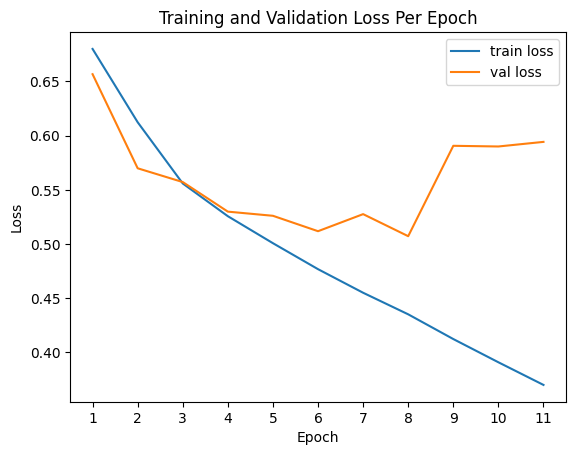

{'lstm_hidden_dim': 256, 'semantic_output_dim': 256, 'feature_config': {'u_v': False, 'diff': True, 'product': True}, 'lstm_layers': 2, 'style_output_dim': 128, 'final_output_dim': 64, 'dropout': 0.4, 'learning_rate': 0.0002, 'weight_decay': 0, 'batch_size': 128}


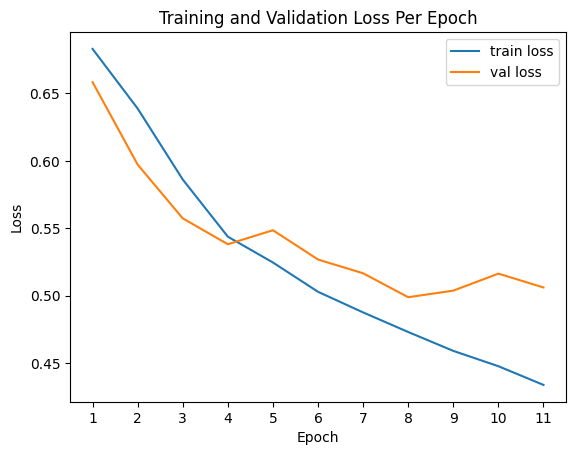

{'lstm_hidden_dim': 256, 'semantic_output_dim': 64, 'feature_config': {'u_v': True, 'diff': True, 'product': False}, 'lstm_layers': 3, 'style_output_dim': 128, 'final_output_dim': 32, 'dropout': 0.4, 'learning_rate': 0.0005, 'weight_decay': 0.0001, 'batch_size': 128}


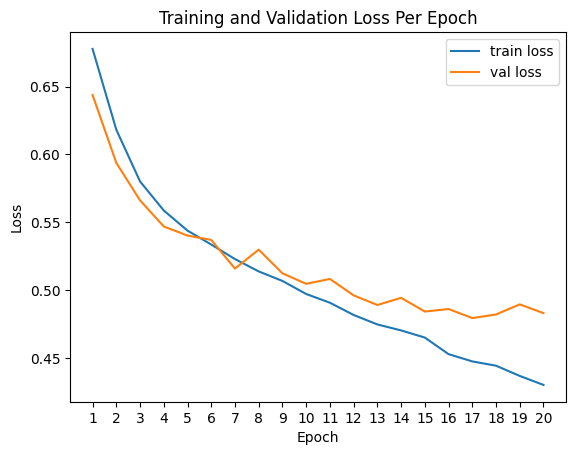

{'lstm_hidden_dim': 256, 'semantic_output_dim': 64, 'feature_config': {'u_v': True, 'diff': True, 'product': True}, 'lstm_layers': 3, 'style_output_dim': 64, 'final_output_dim': 128, 'dropout': 0.5, 'learning_rate': 0.0002, 'weight_decay': 0, 'batch_size': 128}


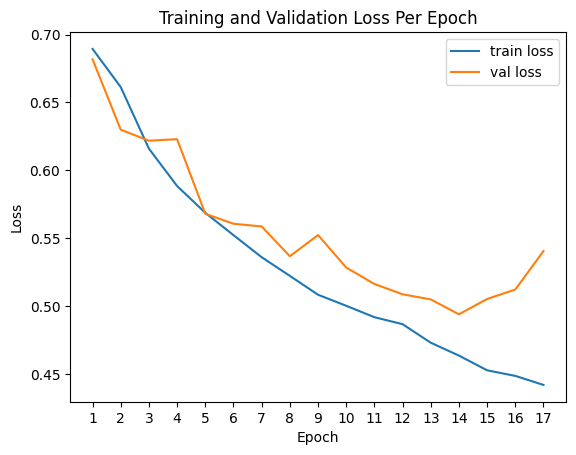

{'lstm_hidden_dim': 256, 'semantic_output_dim': 256, 'feature_config': {'u_v': True, 'diff': True, 'product': False}, 'lstm_layers': 1, 'style_output_dim': 256, 'final_output_dim': 64, 'dropout': 0.5, 'learning_rate': 0.0005, 'weight_decay': 0, 'batch_size': 128}


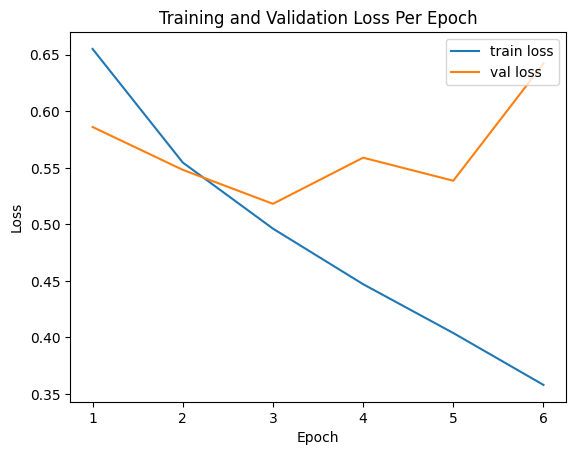

{'lstm_hidden_dim': 256, 'semantic_output_dim': 256, 'feature_config': {'u_v': False, 'diff': True, 'product': False}, 'lstm_layers': 2, 'style_output_dim': 128, 'final_output_dim': 32, 'dropout': 0.3, 'learning_rate': 0.0005, 'weight_decay': 0, 'batch_size': 128}


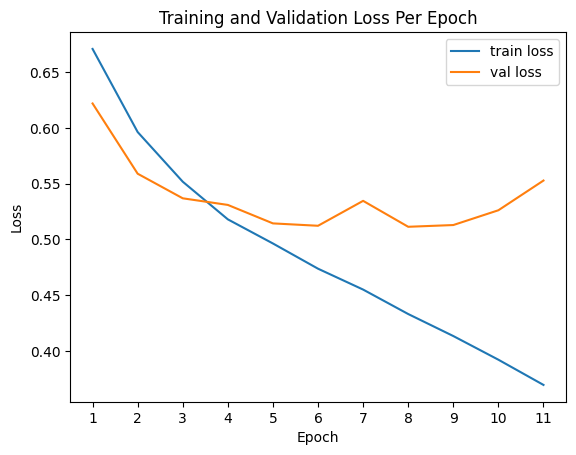

{'lstm_hidden_dim': 256, 'semantic_output_dim': 128, 'feature_config': {'u_v': True, 'diff': True, 'product': False}, 'lstm_layers': 3, 'style_output_dim': 256, 'final_output_dim': 64, 'dropout': 0.4, 'learning_rate': 0.0002, 'weight_decay': 0.0001, 'batch_size': 128}


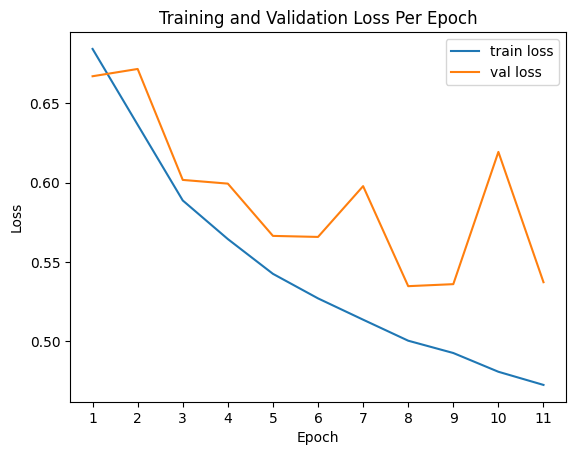

{'lstm_hidden_dim': 256, 'semantic_output_dim': 256, 'feature_config': {'u_v': True, 'diff': True, 'product': True}, 'lstm_layers': 1, 'style_output_dim': 64, 'final_output_dim': 64, 'dropout': 0.4, 'learning_rate': 0.0002, 'weight_decay': 0, 'batch_size': 64}


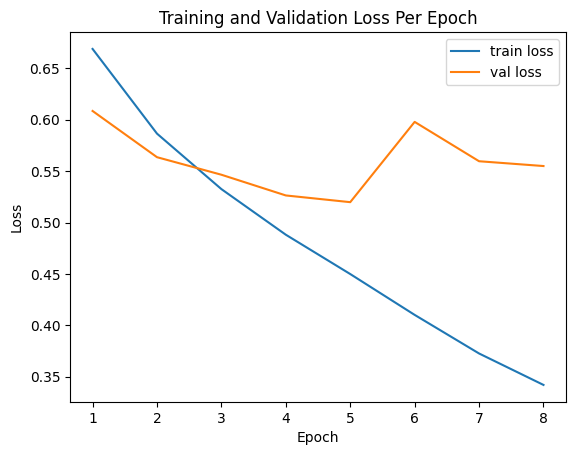

{'lstm_hidden_dim': 256, 'semantic_output_dim': 64, 'feature_config': {'u_v': False, 'diff': True, 'product': True}, 'lstm_layers': 2, 'style_output_dim': 128, 'final_output_dim': 64, 'dropout': 0.4, 'learning_rate': 0.0005, 'weight_decay': 0.0001, 'batch_size': 64}


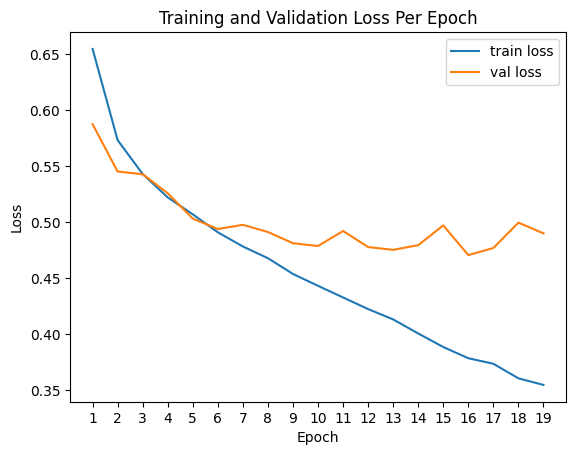

{'lstm_hidden_dim': 256, 'semantic_output_dim': 128, 'feature_config': {'u_v': False, 'diff': True, 'product': True}, 'lstm_layers': 2, 'style_output_dim': 64, 'final_output_dim': 16, 'dropout': 0.4, 'learning_rate': 0.0002, 'weight_decay': 1e-05, 'batch_size': 128}


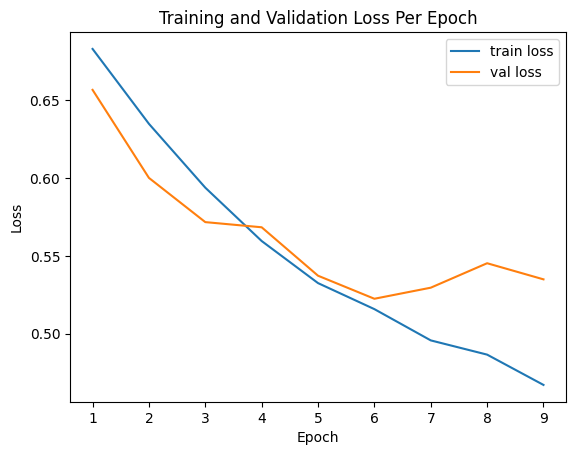

{'lstm_hidden_dim': 256, 'semantic_output_dim': 64, 'feature_config': {'u_v': False, 'diff': True, 'product': False}, 'lstm_layers': 2, 'style_output_dim': 256, 'final_output_dim': 32, 'dropout': 0.5, 'learning_rate': 0.0002, 'weight_decay': 1e-05, 'batch_size': 128}


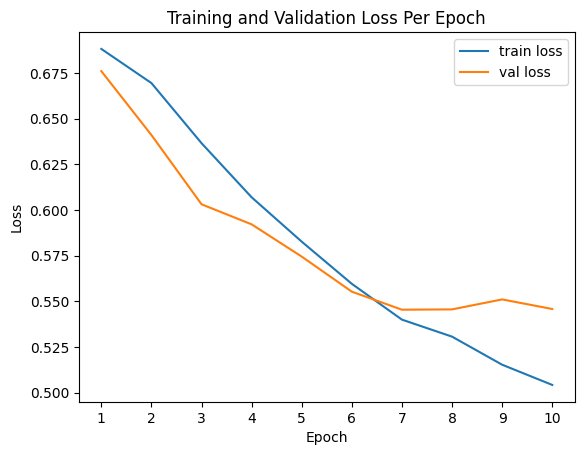

{'lstm_hidden_dim': 256, 'semantic_output_dim': 128, 'feature_config': {'u_v': True, 'diff': True, 'product': True}, 'lstm_layers': 2, 'style_output_dim': 256, 'final_output_dim': 64, 'dropout': 0.4, 'learning_rate': 0.0002, 'weight_decay': 0, 'batch_size': 64}


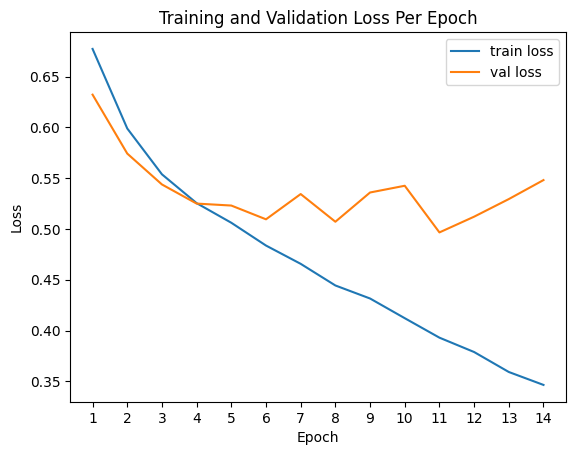

{'lstm_hidden_dim': 256, 'semantic_output_dim': 128, 'feature_config': {'u_v': True, 'diff': True, 'product': True}, 'lstm_layers': 3, 'style_output_dim': 128, 'final_output_dim': 64, 'dropout': 0.4, 'learning_rate': 0.0005, 'weight_decay': 0.0001, 'batch_size': 128}


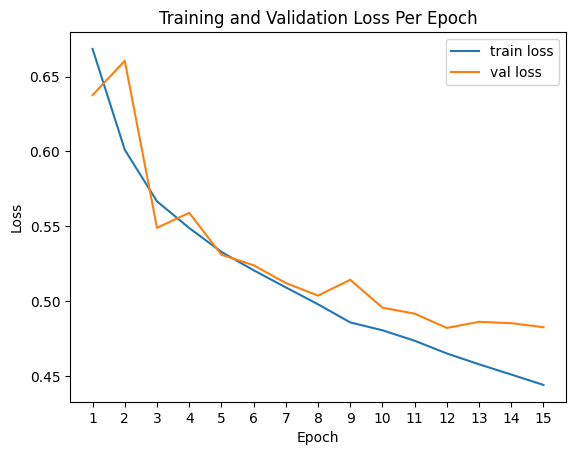

{'lstm_hidden_dim': 256, 'semantic_output_dim': 64, 'feature_config': {'u_v': False, 'diff': False, 'product': True}, 'lstm_layers': 3, 'style_output_dim': 64, 'final_output_dim': 32, 'dropout': 0.4, 'learning_rate': 0.0002, 'weight_decay': 0, 'batch_size': 128}


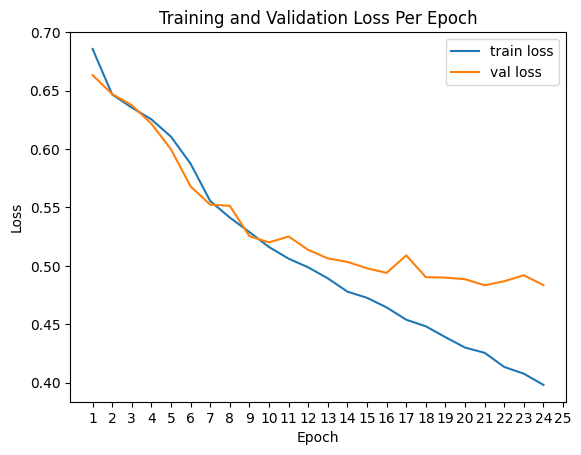

{'lstm_hidden_dim': 256, 'semantic_output_dim': 128, 'feature_config': {'u_v': True, 'diff': True, 'product': True}, 'lstm_layers': 1, 'style_output_dim': 64, 'final_output_dim': 32, 'dropout': 0.4, 'learning_rate': 0.0005, 'weight_decay': 0, 'batch_size': 128}


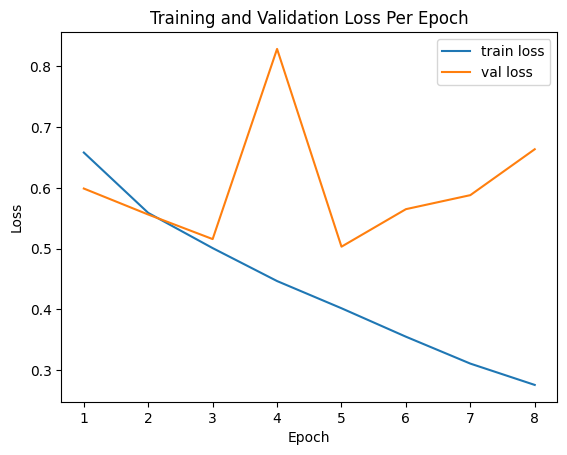

In [35]:
for history in histories:
    print(history["hyperparameters"])
    x_values = np.arange(1, len(history["train_loss"]) + 1)
    y_train_loss = history["train_loss"]
    y_val_loss = history["val_loss"]
    
    plt.xticks(np.linspace(1, len(history["train_loss"]) + 1, len(history["train_loss"]) + 1))
    plt.plot(x_values, y_train_loss, label="train loss")
    plt.plot(x_values, y_val_loss, label="val loss")
    
    plt.title("Training and Validation Loss Per Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend(loc="upper right")
    
    plt.show()

# Validation

In [36]:
val_predictions, val_labels = [], []
best_model.eval()

with torch.no_grad():
    for batch in val_loader:
        val_text_1 = batch["text_1"].to(device)
        val_text_2 = batch["text_2"].to(device)
        val_style_diff = batch["style_diff"].to(device)
        labels = batch["label"].to(device).unsqueeze(1)

        with autocast("cuda" if torch.cuda.is_available() else "cpu"):
            outputs = best_model(val_text_1, val_text_2, val_style_diff)

        predictions = (torch.sigmoid(outputs) > 0.5).float()
        val_predictions.extend(predictions.cpu().numpy().flatten())
        val_labels.extend(labels.cpu().numpy().flatten())
    

val_results_df = val_df.copy()
val_results_df["predicted_label"] = val_predictions
val_results_df["actual_label"] = val_labels

In [37]:
# Evaluation metrics
def get_accuracy(predicted, actual):
    results = predicted == actual
    return results.sum() / results.count()

def get_tp(predicted, actual, class_label):
    return ((actual == class_label) & (predicted == class_label)).sum()

def get_fp(predicted, actual, class_label):
    return ((actual != class_label) & (predicted == class_label)).sum()

def get_fn(predicted, actual, class_label):
    return ((actual == class_label) & (predicted != class_label)).sum()

def get_support(actual, class_label):
    return (actual == class_label).sum()

def get_precision(predicted, actual, class_label):
    tp = get_tp(predicted, actual, class_label)
    fp = get_fp(predicted, actual, class_label)
    
    if (tp + fp) == 0:
        return 0
        
    return tp / (tp + fp)

def get_recall(predicted, actual, class_label):
    tp = get_tp(predicted, actual, class_label)
    fn = get_fn(predicted, actual, class_label)

    if (tp + fn) == 0:
        return 0
        
    return tp / (tp + fn)
    
def get_f1(predicted, actual, class_label):
    precision = get_precision(predicted, actual, class_label)
    recall = get_recall(predicted, actual, class_label)

    if (precision + recall) == 0:
        return 0
    
    return (2 * precision * recall) / (precision + recall)

def get_macro_precision(predicted, actual):
    positive_precision = get_precision(predicted, actual, 1)
    negative_precision = get_precision(predicted, actual, 0)
    return (positive_precision + negative_precision) / 2

def get_macro_recall(predicted, actual):
    positive_recall = get_recall(predicted, actual, 1)
    negative_recall = get_recall(predicted, actual, 0)
    return (positive_recall + negative_recall) / 2

def get_macro_f1(predicted, actual):
    positive_f1 = get_f1(predicted, actual, 1)
    negative_f1 = get_f1(predicted, actual, 0)
    return (positive_f1 + negative_f1) / 2

def get_weighted_macro_precision(predicted, actual):
    if actual.count() == 0:
        return 0
    
    positive_precision = get_precision(predicted, actual, 1)
    negative_precision = get_precision(predicted, actual, 0)

    weighted_positive_precision = positive_precision * (get_support(actual, 1) / actual.count())
    weighted_negative_precision = negative_precision * (get_support(actual, 0) / actual.count())
    
    return weighted_positive_precision + weighted_negative_precision

def get_weighted_macro_recall(predicted, actual):
    if actual.count() == 0:
        return 0
        
    positive_recall = get_recall(predicted, actual, 1)
    negative_recall = get_recall(predicted, actual, 0)

    weighted_positive_recall = positive_recall * (get_support(actual, 1) / actual.count())
    weighted_negative_recall = negative_recall * (get_support(actual, 0) / actual.count())
    
    return weighted_positive_recall + weighted_negative_recall

def get_weighted_macro_f1(predicted, actual):
    if actual.count() == 0:
        return 0
        
    positive_f1 = get_f1(predicted, actual, 1)
    negative_f1 = get_f1(predicted, actual, 0)

    weighted_positive_f1 = positive_f1 * (get_support(actual, 1) / actual.count())
    weighted_negative_f1 = negative_f1 * (get_support(actual, 0) / actual.count())
    
    return weighted_positive_f1 + weighted_negative_f1

def get_micro_precision(predicted, actual):
    tp = get_tp(predicted, actual, 1) + get_tp(predicted, actual, 0)
    fp = get_fp(predicted, actual, 1) + get_fp(predicted, actual, 0)

    if (tp + fp) == 0:
        return 0
    
    return tp / (tp + fp)

def get_micro_recall(predicted, actual):
    tp = get_tp(predicted, actual, 1) + get_tp(predicted, actual, 0)
    fn = get_fn(predicted, actual, 1) + get_fn(predicted, actual, 0)

    if (tp + fn) == 0:
        return 0
    
    return tp / (tp + fn)

def get_micro_f1(predicted, actual):
    micro_precision = get_micro_precision(predicted, actual)
    micro_recall = get_micro_recall(predicted, actual)

    if (micro_precision + micro_recall) == 0:
        return 0

    return (2 * micro_precision * micro_recall) / (micro_precision + micro_recall)

def report_metrics(results_df):
    predicted, actual = results_df["predicted_label"], results_df["actual_label"]
    
    accuracy = get_accuracy(predicted, actual)
    macro_precision = get_macro_precision(predicted, actual)
    macro_recall = get_macro_recall(predicted, actual)
    macro_f1 = get_macro_f1(predicted, actual)
    weighted_macro_precision = get_weighted_macro_precision(predicted, actual)
    weighted_macro_recall = get_weighted_macro_recall(predicted, actual)
    weighted_macro_f1 = get_weighted_macro_f1(predicted, actual)

    # note that micro metrics are the same as accuracy in binary classification
    
    # micro_precision = get_micro_precision(predicted, actual)
    # micro_recall = get_micro_recall(predicted, actual)
    # micro_f1 = get_micro_f1(predicted, actual)

    print(f"Accuracy: {accuracy}")
    print(f"Macro Precision: {macro_precision}")
    print(f"Macro Recall: {macro_recall}")
    print(f"Macro F1: {macro_f1}")
    print(f"Weighted Macro Precision: {weighted_macro_precision}")
    print(f"Weighted Macro Recall: {weighted_macro_recall}")
    print(f"Weighted Macro F1: {weighted_macro_f1}")
    # print(f"Micro Precision: {micro_precision}")
    # print(f"Micro Recall: {micro_recall}")
    # print(f"Micro F1: {micro_f1}")

report_metrics(val_results_df)

Accuracy: 0.7492074086434173
Macro Precision: 0.7491087722347374
Macro Recall: 0.749118430763307
Macro F1: 0.7491134136188993
Weighted Macro Precision: 0.7492126459748516
Weighted Macro Recall: 0.7492074086434173
Weighted Macro F1: 0.7492098395492237


# Testing

In [ ]:
# !find -type f -name '*predictions*' -delete

In [1]:
test_predictions = []
model.eval()

with torch.no_grad():
    for batch in test_loader:
        test_text_1 = batch["text_1"].to(device)
        test_text_2 = batch["text_2"].to(device)
        test_style_diff = batch["style_diff"].to(device)

        with autocast("cuda" if torch.cuda.is_available() else "cpu"):
            outputs = model(test_text_1, test_text_2, test_style_diff)

        predictions = (torch.sigmoid(outputs) > 0.5).float()
        test_predictions.extend(predictions.cpu().numpy().flatten())
    

test_results_df = test_df.copy()
test_results_df["predicted_label"] = test_predictions

NameError: name 'model' is not defined

In [ ]:
import time

def save_predictions(predictions, prefix):
    predictions.to_csv(
        f"/kaggle/working/{prefix}_{time.time()}.csv",
        index=False,
        header=False
    )

# save validation predictions
save_predictions(val_results_df["predicted_label"], "val_predictions")
    
# save test predictions
save_predictions(test_results_df["predicted_label"], "test_predictions")

# Prediction

In [ ]:
from prompt_toolkit.shortcuts import progress_bar
def predict(text_1, text_2):
    # get style diff vectors
    # encode text_1 and text_2
    # pass text_1, text_2, style_diff to the model (eval mode)
    # run `prediction = (torch.sigmoid(output) > 0.5).float()` on the output
    pass